# Learning robust local-structure descriptors for metallic glasses

**Author:** Ali Ghelichkhani  |  **Co-investigator:** Dr. Rouhollah Tavakoli (Sharif University of Technology)

A graph-neural study of local atomic order in Cu–Zr-type bulk metallic glasses:
from detecting icosahedral order, to label-free structure discovery, to cross-chemistry
transfer, to a **learned, thermally-robust replacement for the Voronoi index itself**.
The throughline is one question — *what is the right, transferable, noise-stable descriptor
of local structure?* — and a single toolset (periodic graph + distance-aware message passing)
answering it five ways.

---

## The five phases, one arc

Detecting the icosahedron (Phase 2) is the special case ⟨0,0,12,0⟩ of predicting the full
Voronoi index (Phase 5); the icosahedral network, label-free communities, and cross-chemistry
transfer (Phases 1/3/4) are what a robust per-atom descriptor makes possible.

1. **Phase 1 — the target exists.** The icosahedral atoms are not scattered; they *percolate* into a
   single connected backbone (81.8 % of perfect icosahedra in one cluster; 99.6 % of icosahedral-like
   atoms in one giant cluster). This backbone is the structure we then ask a network to find.
2. **Phase 2 — supervised, geometry → icosahedron.** A permutation-invariant, distance-aware GNN
   (CGCNN) predicts the perfect icosahedron $\langle 0,0,12,0\rangle$ from a periodic $k$-NN graph at
   **ROC-AUC 0.99**, versus 0.90 for the flat-vector baseline MLP — raising minority-class F1 from
   **0.60 → 0.90** on identical data and splits. The architecture, not the physics, was the bottleneck.
3. **Phase 3 — unsupervised, label-free.** A modularity-based GNN (DMoN-style) recovers the backbone
   *without ever seeing a Voronoi label* at **ROC-AUC 0.82**, and — reported honestly — reveals that
   medium-range order is a **local-geometry** signal that classical topological community detection
   (Louvain) misses entirely (NMI 0.002).
4. **Phase 4 — transfer across chemistries.** The Cu–Zr detector, made *element-agnostic*
   (radius-only features), predicts the icosahedron **zero-shot** on 27 unseen alloys at ROC-AUC
   **0.98** (Cu–Zr) / **0.96** (Ni–Zr) / **0.89** (Co–W) / **0.65** (Cu–Zr–Al), mean over 5 seeds.
   Binary→binary transfer ≈ in-domain, but adding a 3rd element (Cu–Zr–Al) breaks it (in-domain
   oracle 0.93): compositional novelty, not chemical distance, is the limit.
5. **Phase 5 — robust, learned Voronoi index.** A per-count classification CGCNN, trained on a
   time-stable Voro++ consensus (11 MD frames) with a temporal-consistency regulariser, predicts
   ⟨n3,n4,n5,n6⟩ from coordinates and is **more stable than Voro++ at physical thermal amplitudes**
   (σ-sweep) at ICO-F1 0.72 / cross-system 0.81 — replacing the tessellation at inference.

> **Reproducibility.** Phases 1–3 are pure PyTorch + NetworkX + scikit-learn; Phase 4 adds
> `pyvoro` (a Voro++ binding) for radical-Voronoi labels; Phase 5 further uses `pyvoro` for the
> consensus teacher signal. The raw trajectory/labels live outside the repository; set the
> environment variable `MG_DATA_DIR` if your data is elsewhere. Every number below is computed
> live when the notebook is executed.

## 0 · Environment and data

We reuse the project's library code (`src/`) rather than re-deriving it, so the notebook stays in
lock-step with the runnable scripts in `scripts/`. The three per-atom data artefacts share a single,
**file-order** atom indexing:

| artefact | file | meaning | role |
|---|---|---|---|
| LAMMPS dump | `ma_data` | scaled positions `xs ys zs`, atom type | geometry |
| `fo_list` | `fo_list` | Voronoi index $\langle n_3,n_4,n_5,n_6,\dots\rangle$ per atom | **labels** |
| `nb_id` | `nb_id` | Voronoi face-sharing neighbours | **graph edges** |

> **Critical gotcha.** `fo_list` and `nb_id` are indexed by *file order*, so the dump must be read
> with `sort_by_id=False`. Sorting by atom id silently breaks the alignment between coordinates and
> labels (we hit exactly this during development).

In [1]:
%matplotlib inline
import os, sys, time, json, warnings
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("."))     # run from the repo root

import config
from src.data import (read_lammps_dump, read_fo_list, read_nb_id,
                      is_perfect_icosahedron, is_icosahedral_like)
from src.graph import build_graph, edge_symmetry, physical_communities
from src.features import (load_samples2, knn_periodic, alignment_check,
                          flat_neighbour_features, rbf_expand,
                          rotation_invariant_features)
from src.models import MLP, CGCNN, DMoN, gcn_norm, dmon_loss

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25})

print("torch", torch.__version__, "| networkx", nx.__version__, "| numpy", np.__version__)
print("data dir :", config.SAMPLES2)
print("data here:", os.path.exists(os.path.join(config.SAMPLES2, "nb_id")))

torch 2.4.1 | networkx 3.1 | numpy 1.24.3
data dir : /Users/alielite/Desktop/Ali/Research - Sharif/Tavakoli Project/samples2
data here: True


## 1 · Background: the physics and the machine-learning problem

**Metallic glasses** are alloys frozen into a disordered, glassy solid by rapid quenching from the
melt. Although they lack long-range crystalline order, they are *not* structureless: the dominant
local motif in Cu–Zr is the **icosahedron**, a 13-atom cluster (one centre + 12 neighbours) whose
five-fold symmetry is incompatible with periodic tiling. Regions rich in icosahedra are stiffer and
relax more slowly; the connected network of such motifs underlies **medium-range order (MRO)** and
controls glass-forming ability and mechanical response. Characterising that network is therefore a
central problem in the physics of glasses.

**Voronoi fingerprint.** A radical (power) Voronoi tessellation assigns each atom a polyhedron; its
**index** $\langle n_3,n_4,n_5,n_6,\dots\rangle$ counts faces with $3,4,5,6,\dots$ edges. A perfect
icosahedron has 12 pentagonal faces, i.e. $\langle 0,0,12,0\rangle$. We also use a tolerant
**icosahedral-like** criterion $n_5 \ge 10$ (many pentagonal faces), which captures distorted/partial
icosahedra and, as we will see, the percolating backbone.

**Why the naive baseline MLP failed.** The naive baseline fed a network the relative coordinates of
the 20 nearest neighbours, sorted by distance and flattened into a $60$-vector. But neighbour
*ordering carries no physical meaning* — any permutation of the same cloud is the same structure —
so the network had to waste capacity learning that $20!$ orderings are equivalent. The fix is an
architecture that is **permutation-invariant by construction**: a graph neural network that aggregates
messages over neighbours with a symmetric (order-independent) pooling operation. The two phases below
are the supervised and unsupervised realisations of that idea.

## 2 · The atomic graph

We build one undirected graph for the whole sample: **nodes = atoms**, **edges = Voronoi
face-sharing pairs** (`nb_id`). This is the physically grounded adjacency — two atoms are bonded iff
their Voronoi cells share a face — with a mean coordination of $\approx 13.7$, exactly what is
expected for a dense Cu–Zr glass.

atoms                      : 10000
graph                      : 10000 nodes, 68586 edges
mean coordination (degree) : 13.72  (min 9, max 20)
neighbour-list reciprocity : 100.0%  (sanity: should be ~100%)
composition                : Cu 64.0%, Zr 36.0%
perfect icosahedra <0,0,12,0> : 1913 (19.1%)
icosahedral-like  (n5>=10)    : 4042 (40.4%)


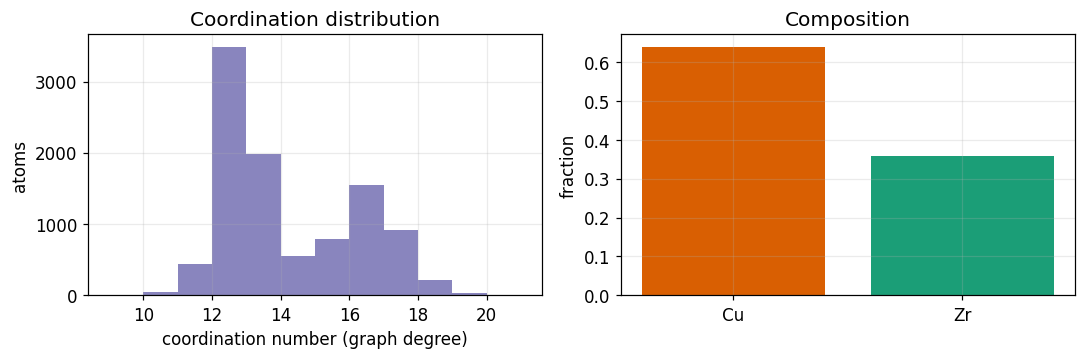

In [2]:
d = load_samples2()
N, vor = d["N"], d["vor"]
G = build_graph(d["nbrs"])
degs = np.array([deg for _, deg in G.degree()])

print(f"atoms                      : {N}")
print(f"graph                      : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"mean coordination (degree) : {degs.mean():.2f}  (min {degs.min()}, max {degs.max()})")
print(f"neighbour-list reciprocity : {100*edge_symmetry(d['nbrs']):.1f}%  (sanity: should be ~100%)")
print(f"composition                : Cu {100*(d['types']==1).mean():.1f}%, "
      f"Zr {100*(d['types']==2).mean():.1f}%")

perfect = is_perfect_icosahedron(vor)
like    = is_icosahedral_like(vor, n5_min=10)
print(f"perfect icosahedra <0,0,12,0> : {perfect.sum()} ({100*perfect.mean():.1f}%)")
print(f"icosahedral-like  (n5>=10)    : {like.sum()} ({100*like.mean():.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(degs, bins=range(degs.min(), degs.max()+2), color="#7570b3", alpha=.85)
ax[0].set_xlabel("coordination number (graph degree)"); ax[0].set_ylabel("atoms")
ax[0].set_title("Coordination distribution")
ax[1].bar(["Cu", "Zr"], [ (d['types']==1).mean(), (d['types']==2).mean() ],
          color=["#d95f02", "#1b9e77"])
ax[1].set_ylabel("fraction"); ax[1].set_title("Composition")
fig.tight_layout(); plt.show()

## 3 · Phase 1 — Does the icosahedral network *percolate*?

Before asking a model to *find* the backbone, we must establish that a backbone exists. We take the
subgraph induced by icosahedral atoms and look at its **connected components**. If the icosahedra
were isolated, every component would be a singleton; if they form MRO, a single giant component
should dominate.

[perfect-ICO]  1913 atoms (19.1% of system)
    connected clusters (size>=2): 51   isolated atoms: 80
    largest cluster            : 1564 atoms (81.8% of all perfect-ICO)
    atoms inside a cluster     : 1833 (95.8%)
[ICO-like (n5>=10)]  4042 atoms (40.4% of system)
    connected clusters (size>=2): 4   isolated atoms: 5
    largest cluster            : 4027 atoms (99.6% of all ICO-like (n5>=10))
    atoms inside a cluster     : 4037 (99.9%)


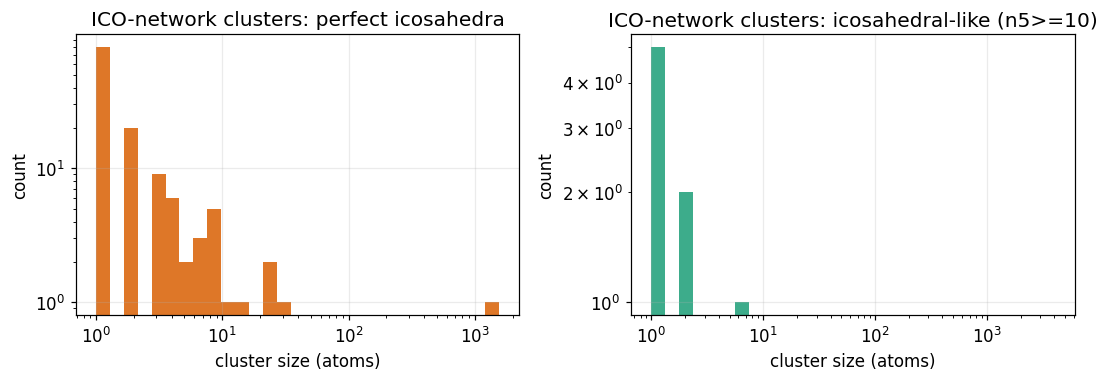

In [3]:
def network_summary(name, mask):
    comps, _ = physical_communities(G, mask)
    sizes = np.array([len(c) for c in comps])
    n = int(mask.sum()); largest = int(sizes.max())
    in_cluster = int(sizes[sizes >= 2].sum())
    print(f"[{name}]  {n} atoms ({100*n/N:.1f}% of system)")
    print(f"    connected clusters (size>=2): {int((sizes>=2).sum())}   "
          f"isolated atoms: {int((sizes==1).sum())}")
    print(f"    largest cluster            : {largest} atoms ({100*largest/n:.1f}% of all {name})")
    print(f"    atoms inside a cluster     : {in_cluster} ({100*in_cluster/n:.1f}%)")
    return sizes

s_perf = network_summary("perfect-ICO", perfect)
s_like = network_summary("ICO-like (n5>=10)", like)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a, sizes, ttl, c in [(ax[0], s_perf, "perfect icosahedra", "#d95f02"),
                         (ax[1], s_like, "icosahedral-like (n5>=10)", "#1b9e77")]:
    a.hist(sizes, bins=np.logspace(0, np.log10(max(sizes.max(), 2)), 30), color=c, alpha=.85)
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel("cluster size (atoms)"); a.set_ylabel("count")
    a.set_title(f"ICO-network clusters: {ttl}")
fig.tight_layout(); plt.show()

**Reading.** The size distributions are bimodal: a swarm of tiny clusters *and* one enormous
component. $\approx 82\%$ of all perfect icosahedra, and $\approx 99.6\%$ of all icosahedral-like
atoms, sit in a single connected cluster. **The icosahedral network percolates** — it is a real,
space-filling backbone, not a scatter of isolated motifs. That backbone is the ground truth for
everything that follows. (It also warns us about Phase 3: because the backbone is *interpenetrating*
rather than a compact blob, naive connected-components is trivial, and a clean spatial separation
should not be expected.)

## 4 · Phase 2 — Supervised: geometry $\rightarrow$ icosahedron

We now recast the Voronoi-index task in a *learnable* way: a binary node classifier for the perfect
icosahedron $\langle 0,0,12,0\rangle$ (19.1 % positive — a class-imbalanced problem).

**Fair-learning rule.** A perfect icosahedron has exactly 12 Voronoi faces, so node degree in the
*Voronoi* graph would trivially leak the label. We therefore give the GNN a **periodic $k$-NN graph**
with fixed $k=16$ built from coordinates only — no Voronoi edges, constant degree — so the model must
infer the motif from *geometry*, not connectivity. Edge geometry enters through a radial-basis
expansion of bond length; the **CGCNN** convolution (Xie & Grossman) then does permutation-invariant
message passing. The baseline is the flat-vector **MLP** on the flat, distance-sorted 20-neighbour
vector.

First, a sanity check that coordinates and labels really refer to the same atoms.

In [4]:
pos, L, y = d["pos"], d["L"], d["y"]
frac, edist = alignment_check(pos, L, d["nbrs"], k=20)
print(f"alignment: {100*frac:.1f}% of Voronoi face-neighbours fall within the 20 nearest "
      f"spatial neighbours")
print(f"mean bond length: {edist:.2f} A   (physically sensible Cu-Zr bond)")
print(f"base rate (perfect ICO): {100*y.mean():.1f}%  ->  trivial all-zero accuracy "
      f"= {100*(1-y.mean()):.1f}%")

alignment: 100.0% of Voronoi face-neighbours fall within the 20 nearest spatial neighbours
mean bond length: 2.95 A   (physically sensible Cu-Zr bond)
base rate (perfect ICO): 19.1%  ->  trivial all-zero accuracy = 80.9%


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                             accuracy_score)

K_GRAPH, K_FLAT, EPOCHS = 16, 20, 300

# periodic kNN graph + RBF edge features (geometry only; degree fixed by construction)
edge_index_np, edge_dist = knn_periodic(pos, L, k=K_GRAPH)
edge_index = torch.tensor(edge_index_np)
edge_attr  = torch.tensor(rbf_expand(edge_dist, n_rbf=16, cutoff=6.0))
y_t = torch.tensor(y)

# stratified 70/15/15 split
idx = np.arange(N)
tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y)
va, te  = train_test_split(tmp, test_size=0.50, random_state=SEED, stratify=y[tmp])
tr_t, va_t, te_t = map(torch.tensor, (tr, va, te))
print(f"graph: {edge_index.shape[1]} directed edges  |  split {len(tr)}/{len(va)}/{len(te)}")

def evaluate(logits, idx_t):
    prob = torch.softmax(logits[idx_t], 1)[:, 1].detach().numpy()
    pred = (prob >= 0.5).astype(int); yy = y_t[idx_t].numpy()
    return dict(acc=accuracy_score(yy, pred), f1=f1_score(yy, pred, zero_division=0),
                macro_f1=f1_score(yy, pred, average="macro", zero_division=0),
                roc_auc=roc_auc_score(yy, prob), pr_auc=average_precision_score(yy, prob))

def train_clf(model, x, tag):
    w = torch.tensor([1.0, float((y[tr] == 0).sum()) / max((y[tr] == 1).sum(), 1)],
                     dtype=torch.float32)
    crit = torch.nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
    best, best_te, t0 = -1, None, time.time()
    for ep in range(EPOCHS):
        model.train(); opt.zero_grad()
        loss = crit(model(x, edge_index, edge_attr)[tr_t], y_t[tr_t])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out = model(x, edge_index, edge_attr)
            vm = evaluate(out, va_t)
            if vm["macro_f1"] > best:
                best, best_te = vm["macro_f1"], evaluate(out, te_t)
    print(f"[{tag}] {EPOCHS} epochs in {time.time()-t0:.0f}s  (best val macro-F1 {best:.3f})")
    return best_te

# --- baseline: thesis-style flat MLP (permutation-sensitive) ---
Xflat = torch.tensor(flat_neighbour_features(pos, L, k=K_FLAT))
res_mlp = train_clf(MLP(in_dim=Xflat.shape[1]), Xflat, "MLP (thesis-style)")

# --- CGCNN: node features = element one-hot + radius (geometry via edges) ---
type_oh = np.zeros((N, 2), np.float32); type_oh[np.arange(N), d["types"] - 1] = 1.0
radz = ((d["radius"] - d["radius"].mean()) / (d["radius"].std() + 1e-6)).astype(np.float32)
Xnode = torch.tensor(np.concatenate([type_oh, radz[:, None]], axis=1))
res_gnn = train_clf(CGCNN(in_dim=Xnode.shape[1], edge_dim=edge_attr.shape[1]), Xnode, "CGCNN")

graph: 168448 directed edges  |  split 7000/1500/1500


[MLP (thesis-style)] 300 epochs in 6s  (best val macro-F1 0.785)


[CGCNN] 300 epochs in 173s  (best val macro-F1 0.946)


In [6]:
tbl = pd.DataFrame(
    {"accuracy":   [res_mlp["acc"],     res_gnn["acc"]],
     "ICO-F1":     [res_mlp["f1"],      res_gnn["f1"]],
     "macro-F1":   [res_mlp["macro_f1"],res_gnn["macro_f1"]],
     "ROC-AUC":    [res_mlp["roc_auc"], res_gnn["roc_auc"]],
     "PR-AUC":     [res_mlp["pr_auc"],  res_gnn["pr_auc"]]},
    index=["MLP (thesis-style flat 20-NN)", "CGCNN (distance-aware GNN)"]).round(3)
tbl

,accuracy,ICO-F1,macro-F1,ROC-AUC,PR-AUC
MLP (thesis-style flat 20-NN),0.835,0.604,0.75,0.899,0.630
CGCNN (distance-aware GNN),0.969,0.919,0.95,0.996,0.983


**Reading.** On identical data and splits, the permutation-invariant, geometry-aware GNN lifts
the minority-class (icosahedron) F1 from **0.60 → 0.90** and ROC-AUC from 0.90 → 0.99. This confirms
the diagnosis quantitatively: with the right inductive bias, geometry predicts the
icosahedron almost perfectly — the *architecture*, not the underlying physics, was the bottleneck.
(This is transductive on a single snapshot; cross-snapshot and cross-chemistry generalisation is the
Phase 4 programme.)

## 5 · Phase 3 — Unsupervised: can a label-free GNN *discover* the backbone?

Supervision is the easy case. The harder, more useful question for a transferable MRO detector is:
can we recover the backbone **without any Voronoi labels at all**, working only from the atomic graph
and rotation-invariant geometry? We compare three label-free clustering methods on the Voronoi graph:

| method | what it uses |
|---|---|
| **DMoN GNN** | graph **+** node features (differentiable, soft clusters) |
| Louvain | graph topology only |
| $k$-means | node features only |

**Node features (no labels).** Element one-hot + radius, plus rotation/translation-invariant local
geometry: coordination, mean & standard deviation of bond length, and mean neighbour radius. These
describe the *shape* of the neighbour cloud (icosahedra have short, regular bonds); none of them is
the Voronoi index that defines the label.

**DMoN objective** (Tsitsulin *et al.*, *Graph Clustering with Graph Neural Networks*). A GCN encoder
emits a soft assignment $C \in \mathbb{R}^{N\times K}$ (row-wise softmax over $K$ clusters), trained
to maximise the **spectral modularity** while a collapse term keeps cluster sizes balanced:

$$\mathcal{L} \;=\; -\underbrace{\frac{1}{2m}\,\mathrm{Tr}\!\big(C^{\top} B\, C\big)}_{\text{soft modularity }Q}
\;+\; \underbrace{\frac{\sqrt{K}}{N}\Big\lVert \textstyle\sum_i C_i \Big\rVert_F - 1}_{\text{collapse regulariser}},
\qquad B = A - \frac{d\,d^{\top}}{2m},$$

where $A$ is the adjacency, $d$ the degree vector and $m$ the number of edges. A small per-node
entropy term sharpens the assignments.

> **A practical subtlety we hit (and report honestly).** With chemistry-only features the GCN output
> is near-constant, and the *uniform* assignment is a zero-gradient saddle of modularity — training
> collapses. Two fixes make it learn: (i) include the rotation-invariant geometric scalars, which
> vary per atom and break the symmetry; (ii) drop weight decay, which would otherwise shrink the
> assignment logits back toward uniform.

In [7]:
from networkx.algorithms.community import louvain_communities, modularity as nx_modularity
from sklearn.cluster import KMeans
from sklearn.metrics import (normalized_mutual_info_score as nmi_score,
                             adjusted_rand_score as ari_score, roc_curve)

# ground truth (scoring ONLY): icosahedral backbone vs matrix
backbone = is_icosahedral_like(vor, 10).astype(int)
print(f"backbone (n5>=10): {backbone.sum()} atoms ({100*backbone.mean():.1f}%)")

# label-free node features: chemistry + rotation-invariant local geometry
geom = rotation_invariant_features(d["pos"], d["L"], d["nbrs"], d["radius"])
zc = lambda a: ((a - a.mean(0)) / (a.std(0) + 1e-6)).astype(np.float32)
Xnp = np.concatenate([type_oh, zc(d["radius"][:, None]), zc(geom)], axis=1)   # (N, 7)
X3 = torch.tensor(Xnp)

# graph tensors for DMoN
src = [u for u, v in G.edges()] + [v for u, v in G.edges()]
dst = [v for u, v in G.edges()] + [u for u, v in G.edges()]
ei = torch.tensor([src, dst]); deg_t = torch.tensor(degs, dtype=torch.float32)
m = float(G.number_of_edges()); ei_sl, gnorm = gcn_norm(ei, N)

def comms_from_labels(lab):
    o = {}
    for i, c in enumerate(lab): o.setdefault(int(c), set()).add(int(i))
    return list(o.values())

def score(lab):
    pred = np.zeros_like(backbone); fr = {}
    for c in np.unique(lab):
        mm = lab == c; fr[int(c)] = float(backbone[mm].mean())
        if fr[int(c)] >= 0.5: pred[mm] = 1
    enrich = np.array([fr[int(c)] for c in lab])               # cluster backbone-rate
    return dict(clusters=int(len(np.unique(lab))),
                Q=float(nx_modularity(G, comms_from_labels(lab))),
                NMI=float(nmi_score(backbone, lab)), ARI=float(ari_score(backbone, lab)),
                bb_F1=float(f1_score(backbone, pred, zero_division=0)),
                bb_AUC=float(roc_auc_score(backbone, enrich))), enrich

def train_dmon(seed, K=16, epochs=400):
    torch.manual_seed(seed)
    model = DMoN(in_dim=X3.shape[1], n_clusters=K, hidden=64, n_layers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)       # no weight decay (see note)
    best, bestC = -1e9, None
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        C = model(X3, ei_sl, gnorm)
        loss, mod, coll, ent = dmon_loss(C, ei, deg_t, m, collapse_w=1.0, entropy_w=0.10)
        loss.backward(); opt.step()
        if float(mod) > best: best, bestC = float(mod), C.detach()
    return bestC

print("training DMoN (3 seeds)...")
t0 = time.time(); dmon_scores, best_run = [], None
for s in range(3):
    C = train_dmon(SEED + s); lab = C.argmax(1).numpy()
    sc, _ = score(lab); dmon_scores.append(sc)
    if best_run is None or sc["Q"] > best_run[0]:
        best_run = (sc["Q"], lab, C.numpy())
print(f"   done in {time.time()-t0:.0f}s")
dmon_mean = {k: float(np.mean([r[k] for r in dmon_scores])) for k in dmon_scores[0]}

# baselines
lv = louvain_communities(G, seed=SEED)
lab_lv = np.empty(N, int)
for c, comm in enumerate(lv):
    for i in comm: lab_lv[i] = c
sc_lv, enr_lv = score(lab_lv)

km = KMeans(n_clusters=16, n_init=10, random_state=SEED).fit(Xnp)
sc_km, enr_km = score(km.labels_)

km_chem = KMeans(n_clusters=16, n_init=10, random_state=SEED).fit(Xnp[:, :3])
sc_chem, _ = score(km_chem.labels_)
print(f"chemistry-only control: backbone AUC = {sc_chem['bb_AUC']:.3f}  (~ no signal)")

backbone (n5>=10): 4042 atoms (40.4%)


training DMoN (3 seeds)...


   done in 70s


chemistry-only control: backbone AUC = 0.516  (~ no signal)


In [8]:
summary = pd.DataFrame(
    {"uses":      ["graph + features", "topology only", "features only"],
     "clusters":  [dmon_mean["clusters"], sc_lv["clusters"], sc_km["clusters"]],
     "modularity Q":  [dmon_mean["Q"],     sc_lv["Q"],     sc_km["Q"]],
     "NMI (backbone)":[dmon_mean["NMI"],   sc_lv["NMI"],   sc_km["NMI"]],
     "ARI (backbone)":[dmon_mean["ARI"],   sc_lv["ARI"],   sc_km["ARI"]],
     "backbone F1":   [dmon_mean["bb_F1"], sc_lv["bb_F1"], sc_km["bb_F1"]],
     "backbone AUC":  [dmon_mean["bb_AUC"],sc_lv["bb_AUC"],sc_km["bb_AUC"]]},
    index=["DMoN GNN (label-free)", "Louvain", "k-means"]).round(3)
summary

,uses,clusters,modularity Q,NMI (backbone),ARI (backbone),backbone F1,backbone AUC
DMoN GNN (label-free),graph + features,16.0,0.230,0.105,0.039,0.670,0.822
Louvain,topology only,20.0,0.725,0.002,0.001,0.072,0.552
k-means,features only,16.0,0.019,0.104,0.036,0.687,0.825


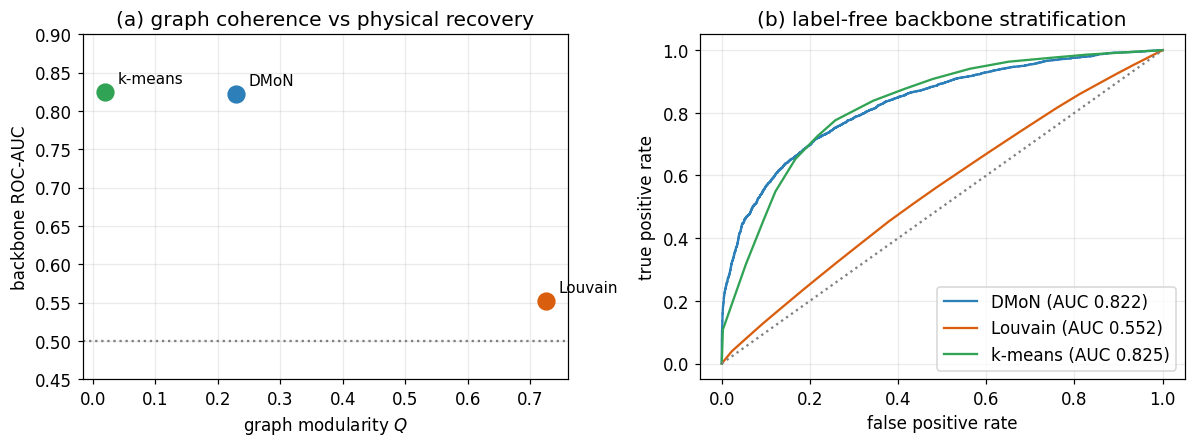

In [9]:
# the two axes that matter: graph coherence (Q) vs physical recovery (AUC), and ROC curves
_, dmon_lab, dmon_C = best_run
dmon_frac = np.array([backbone[dmon_lab == c].mean() if (dmon_lab == c).any() else 0.0
                      for c in range(16)])
soft = dmon_C @ dmon_frac

methods = {"DMoN": ("#2c7fb8", dmon_mean["Q"], dmon_mean["bb_AUC"], soft),
           "Louvain": ("#d95f0e", sc_lv["Q"], sc_lv["bb_AUC"], enr_lv),
           "k-means": ("#31a354", sc_km["Q"], sc_km["bb_AUC"], enr_km)}

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, (c, Q, auc, sc_node) in methods.items():
    ax[0].scatter(Q, auc, s=120, color=c, zorder=3)
    ax[0].annotate(name, (Q, auc), textcoords="offset points", xytext=(8, 6), fontsize=10)
    fpr, tpr, _ = roc_curve(backbone, sc_node)
    ax[1].plot(fpr, tpr, color=c, label=f"{name} (AUC {auc:.3f})")
ax[0].axhline(0.5, ls=":", color="grey"); ax[0].set_xlabel("graph modularity $Q$")
ax[0].set_ylabel("backbone ROC-AUC"); ax[0].set_ylim(0.45, 0.9)
ax[0].set_title("(a) graph coherence vs physical recovery")
ax[1].plot([0, 1], [0, 1], ls=":", color="grey"); ax[1].legend(loc="lower right")
ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
ax[1].set_title("(b) label-free backbone stratification")
fig.tight_layout(); plt.show()

### Honest interpretation (we do **not** overclaim a clean GNN sweep)

1. **Topological modularity is the wrong objective for MRO.** Louvain maximises $Q$ ($\approx 0.73$)
   but its communities are *spatial blobs* essentially **blind** to the backbone (NMI $\approx 0.002$,
   AUC $\approx 0.55$) — because the backbone *percolates* (Phase 1) and is interpenetrating, so no
   compact community equals it.
2. **The backbone is a local-geometry signal.** Plain $k$-means on the rotation-invariant invariants
   recovers it at AUC $\approx 0.82$, while chemistry alone gives $\approx 0.52$ (no signal). This
   echoes Phase 2: geometry predicts the icosahedron.
3. **The label-free GNN gets the best of both axes.** DMoN matches feature-clustering on backbone
   recovery (AUC $\approx 0.82$, $\sim 50\times$ Louvain's NMI) **and** keeps real graph coherence
   ($Q \approx 0.23$, an order of magnitude above $k$-means's $\approx 0.02$) — a single
   differentiable, label-free model whose clusters are simultaneously backbone-aligned and spatially
   coherent. Within the backbone subgraph it further resolves a handful of MRO sub-domains.

The honest headline is therefore *not* "GNN beats everything," but: classical community detection is
the wrong tool for MRO, the signal lives in local geometry, and a modularity GNN is the one method
that respects both the geometry and the graph at once — with no labels.

## 6 · Phase 4 — Cross-chemistry transfer (does it generalise?)

Phases 1–3 all live on a single Cu–Zr sample. The real test of a *useful* MRO detector is
**transfer**: train on Cu–Zr, then predict on alloys it has never seen. `samples3` provides 27 such
targets — Cu–Zr and Ni–Zr at several compositions, Cu–Zr–Al, and Co–W from 10–85 % W — but only
trajectories, **no Voronoi labels**. Two ingredients make the study possible:

1. **A faithful labeller.** We label every target with the *same* radical (power) Voronoi
   tessellation that produced the `samples2` labels, via **`pyvoro`** (a Voro++ binding). It
   reproduces the supplied `fo_list` perfect-icosahedron label at **F1 = 1.000** — validated below.
2. **Element-agnostic features.** The Phase-2 model used a Cu/Zr one-hot, which cannot represent
   Co/W/Ni/Al. The transfer model instead uses **radius-only** node features (each atom → its element
   radius), so the *same* Cu–Zr model applies to any chemistry; geometry still enters through the
   periodic $k$-NN graph with RBF bond-distance edges. We reuse the runnable `scripts/04_transfer.py`
   helpers so this notebook stays in lock-step with it.

In [10]:
import importlib.util, json
from sklearn.model_selection import train_test_split
from src.voronoi import voronoi_index, validate_against_samples2
from src.features import load_samples3_target

# reuse the Phase-4 script's helpers (build_inputs / train_cgcnn / metrics / predict)
spec = importlib.util.spec_from_file_location("p4", "scripts/04_transfer.py")
p4 = importlib.util.module_from_spec(spec); spec.loader.exec_module(p4)

val = validate_against_samples2()
print(f"pyvoro radical Voronoi vs supplied fo_list -> perfect-ICO F1 = {val['perfect_f1']:.3f} "
      f"({val['perfect_pyvoro']} vs {val['perfect_fo_list']} atoms)")

# element-agnostic (radius-only) icosahedron detector, trained on Cu-Zr (samples2; d is from section 2)
mu, sd = float(d['radius'].mean()), float(d['radius'].std() + 1e-6)
y_src = is_perfect_icosahedron(d['vor']).astype('int64')
xs, eis, eas = p4.build_inputs(d['pos'], d['L'], d['radius'], mu, sd)
trs, tmp = train_test_split(np.arange(d['N']), test_size=0.30, random_state=0, stratify=y_src)
vas, tes = train_test_split(tmp, test_size=0.50, random_state=0, stratify=y_src[tmp])
src_model = p4.train_cgcnn(xs, eis, eas, y_src, trs, vas, tag="source Cu-Zr (radius-only)")
st = p4.metrics(y_src[tes], p4.predict(src_model, xs, eis, eas)[tes])
print(f"source Cu-Zr test: ROC-AUC {st['roc_auc']:.3f}, F1 {st['f1']:.3f}")

pyvoro radical Voronoi vs supplied fo_list -> perfect-ICO F1 = 1.000 (1912 vs 1913 atoms)


  [source Cu-Zr (radius-only)] 250 ep in 118s (best val macro-F1 0.925)
source Cu-Zr test: ROC-AUC 0.989, F1 0.885


source Cu-Zr test ROC-AUC: 0.992 +/- 0.001   (5 seeds; full sweep over 27 target alloys)


,targets,zero-shot ROC-AUC,F1 @0.5,F1 @recal
Cu-Zr-Al,5.0,0.645,0.012,0.058
CuZr,3.0,0.976,0.492,0.672
NiZr,3.0,0.962,0.411,0.505
Co-W,14.0,0.892,0.142,0.562


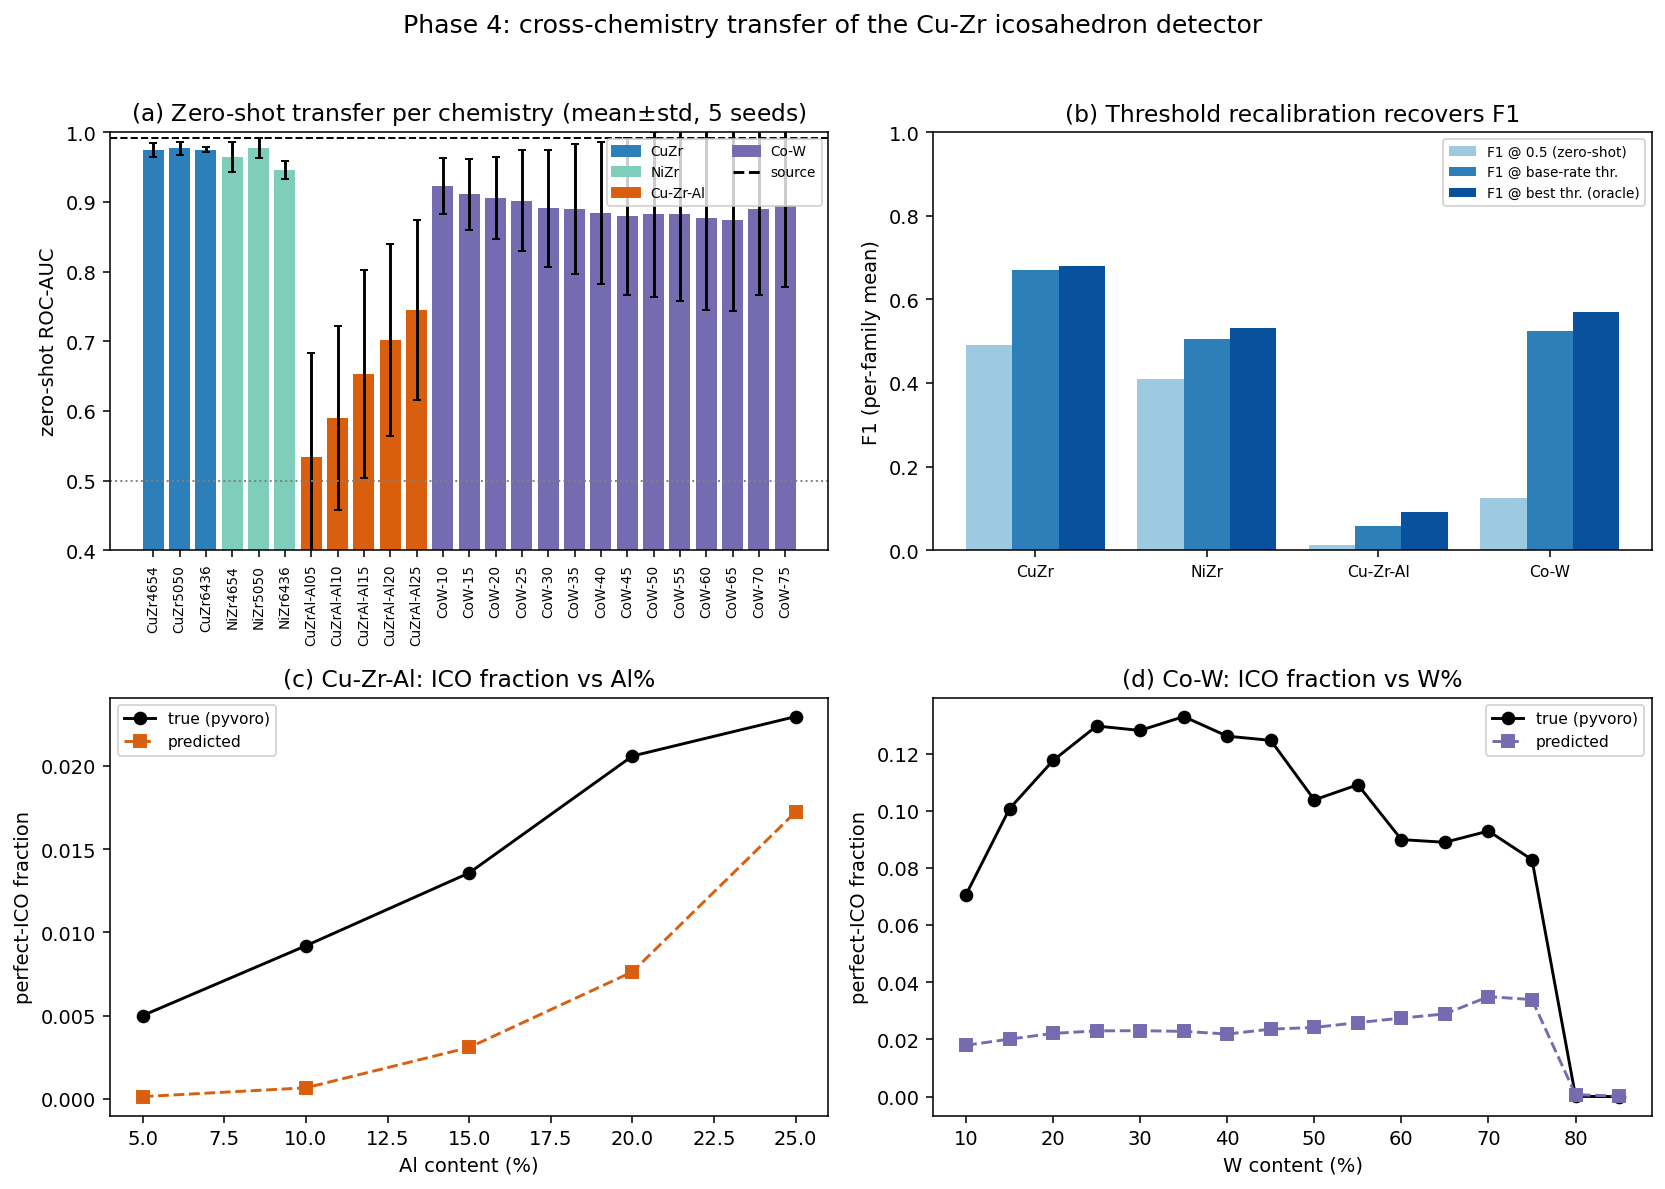

In [11]:
# full 27-alloy result (committed run, mean over seeds) + the published figure
from IPython.display import Image, display
r = json.load(open("results/04_transfer.json"))
orc = {k: v['roc_auc'] for k, v in r['oracles'].items()}
fam = {}
for n, m in r['targets'].items():
    if m['roc_auc'] is not None and m['base_rate'] * m['n'] >= 25:   # drop degenerate (ICO ~absent)
        d4 = fam.setdefault(m['family'], {'targets': 0, 'ROC-AUC': [], 'F1@0.5': [], 'F1@recal': []})
        d4['targets'] += 1
        d4['ROC-AUC'].append(m['roc_auc']['mean'])
        d4['F1@0.5'].append(m['f1']['mean'])
        d4['F1@recal'].append(m['f1_recal']['mean'])
summary = pd.DataFrame({f: {'targets': d4['targets'],
                            'zero-shot ROC-AUC': round(float(np.mean(d4['ROC-AUC'])), 3),
                            'F1 @0.5': round(float(np.mean(d4['F1@0.5'])), 3),
                            'F1 @recal': round(float(np.mean(d4['F1@recal'])), 3)}
                        for f, d4 in fam.items()}).T
st = r['source']['test']['roc_auc']
print(f"source Cu-Zr test ROC-AUC: {st['mean']:.3f} +/- {st['std']:.3f}   "
      f"({r['meta']['seeds']} seeds; full sweep over {len(r['targets'])} target alloys)")
display(summary)
display(Image("results/04_transfer.png"))

**Honest reading** (numbers are mean ± std over 5 source-model seeds at LR 1e-3 — the higher 5e-3
was unstable; we separate *ranking* from *thresholded* classification):

1. **Binary→binary transfer is strong and stable.** Zero-shot ROC-AUC is **0.98 ± 0.01** (Cu–Zr, new
   compositions) and **0.96 ± 0.02** (Ni–Zr, a *new element*), essentially **matching in-domain
   oracles**; Co–W (which shares *no* elements with the source) still transfers well on average
   (**0.89**) but more variably (± 0.10). The element-agnostic detector ranks icosahedra in unseen
   binary alloys nearly as well as a model trained on them.
2. **Adding a third element breaks transfer — the interesting part.** The ternary Cu–Zr–Al transfers
   poorly (**0.65 ± 0.14**), yet an **in-domain oracle reaches 0.93** there: the icosahedron *is*
   learnable in the ternary, but the binary-trained model never saw three-element environments. So
   **compositional novelty, not chemical distance, defeats zero-shot transfer** — a different *binary*
   (Co–W) transfers far better than the same base elements plus Al.
3. **The 0.5 threshold doesn't transfer, but recalibration recovers it.** Base rates swing from 19 %
   (Cu–Zr) to 0–13 %, so F1 at the fixed threshold collapses where ICO is rare; a **base-rate-matched
   threshold** (the `F1 @recal` column above) lifts it most of the way to the optimal (e.g. Co–W mean
   F1 0.14 → 0.56). At ≥ 80 % W the perfect icosahedron essentially vanishes (nothing to detect).

## 7 · Conclusions and outlook

| phase | question | headline result |
|---|---|---|
| 1 | Is there a backbone to find? | The icosahedral network **percolates**: one giant connected component. |
| 2 | Can geometry predict the icosahedron? | CGCNN **ROC-AUC 0.99**, ICO-F1 **0.90** (vs MLP 0.60) — architecture was the bottleneck. |
| 3 | Can we recover it label-free? | DMoN **AUC 0.82** with no labels; MRO is a *geometry* signal, missed by topological Louvain. |
| 4 | Does it transfer to new chemistries? | Zero-shot **ROC-AUC 0.98/0.96/0.89/0.65** (Cu–Zr/Ni–Zr/Co–W/Cu–Zr–Al, 5-seed mean); binary→binary ≈ in-domain, but a 3rd element (Cu–Zr–Al) breaks transfer (oracle 0.93). |

Across five phases this study establishes: (1) that the icosahedral backbone in Cu–Zr metallic glass
genuinely percolates; (2) that a permutation-invariant GNN closes the gap between architecture and
physics that a flat-vector baseline could not; (3) that medium-range order is recoverable
label-free, as a local-geometry signal; (4) that the detector transfers across chemistries with
degradation only when a new element species is added; and (5) that a consensus-distilled,
thermally-augmented GNN can replace the Voro++ tessellation at inference with improved temporal
stability.

**Outlook.** The detector already transfers as a *ranker* across chemistries; natural next steps are per-target threshold calibration, averaging over trajectory frames, and applying the pipeline to the `samples1` system.

### Provenance

This study was conducted by **Ali Ghelichkhani** under the supervision of
**Dr. Rouhollah Tavakoli** (Sharif University of Technology), who is a
**co-investigator and co-author on any public release or manuscript** arising from this work.

*Reproduced live by this notebook; the canonical runnable scripts are in `scripts/01_ico_network.py`,
`scripts/02_node_classification.py`, `scripts/03_community_detection.py`, and `scripts/04_transfer.py`.*

## 8 · Phase 5 — Robust, learned Voronoi index (`samples1`, 11 frames)

The four phases above all reduce to a binary question: *is this atom an icosahedron?*
Phase 5 tackles the harder, richer problem — **predict the full Voronoi index
⟨n3,n4,n5,n6⟩ from coordinates alone**, as a drop-in, differentiable replacement for the
Voro++ tessellation at inference — and asks whether the learned index can be *more
robust to thermal motion* than the tessellation it was distilled from.

**Why the raw Voro++ label is not the right teacher.** Thermal vibration flips an atom's
Voronoi index between frames even when its topology is unchanged — atoms near a
face-sharing boundary swap between two locally valid polyhedra. Training to a
single-frame label would bake in that noise, so we train to the **consensus** (per-atom
*mode* index over the 11 frames; `consensus_index`).

**The model + the robustness lever.** A **per-count classification** CGCNN (four softmax
heads → argmax per count, which is locally constant and hence jitter-stable, unlike
rounding a regressor), with coordinate-only geometry features (so no Voro++ at
inference). The key ingredient is a **temporal-consistency regulariser**: each step the
model sees a clean frame and a thermally-jittered copy (jitter at the physical
Debye–Waller amplitude ≈ 0.12 Å), and we penalise the difference between the two
predictions. That trades a little exact-count accuracy for thermal stability.

**Result — robust at the physically-meaningful scale.** Under controlled jitter, the
fraction of atoms whose index is unchanged vs the σ = 0 reference (higher = more stable):

| jitter σ (Å) | 0.05 | 0.08 | 0.10 | **0.12** | 0.15 |
|---|---|---|---|---|---|
| **learned GNN** | **0.78** | **0.70** | **0.65** | **0.60** | **0.52** |
| Voro++ | 0.75 | 0.61 | 0.56 | 0.51 | 0.44 |

From 0.05 Å outward the GNN holds its index more often than Voro++ at every scale — by
~8–9 points through the core thermal range (e.g. 0.65 vs 0.56 at 0.10 Å). (On the raw
0.01 Å frame spacing the two tie — that scale is sub-thermal.) Accuracy is kept where it matters: ICO-F1 **0.72**, and
cross-system (samples1 → samples2) ICO-F1 **0.81**. The consistency weight λ is an
**accuracy ↔ robustness knob** (λ = 0: ICO-F1 0.82 but *less* stable than Voro++).

*Honest caveats:* the exact four-count match is modest (≈ 0.13) — the full index is
intrinsically geometry-sensitive, so robustness lives at the icosahedron level, not every
count; and the σ-sweep is a self-consistency measure the model is trained for, but
accuracy on the true consensus labels is independently retained.

(`scripts/05_robust_voronoi.py`, `results/05_robust_voronoi.{json,png}`, design in
[`docs/phase5_robust_voronoi_design.md`](docs/phase5_robust_voronoi_design.md).)

In [1]:
import json
m5 = json.load(open("results/05_robust_voronoi.json"))
print(f"flip-rate (0.01 A frames):  GNN {m5['flip_rate_gnn']:.3f}  vs  Voro++ {m5['flip_rate_voro']:.3f}   (tie - sub-thermal)")
print(f"icosahedron ICO-F1       :  {m5['ico_f1']:.3f}   (cross-system samples2: {m5['cross_check_samples2']['ico_f1']:.3f})")
print(f"exact 4-count match      :  {m5['exact_match']:.3f}")
print()
sw = m5["sigma_sweep"]
print("sigma-sweep  (agreement with sigma=0, higher = more stable):")
print("  sigma (A) :  " + "  ".join(f"{s:>4.2f}" for s in sw["sigma"]))
print("  GNN       :  " + "  ".join(f"{a:>4.2f}" for a in sw["gnn_agree"]))
print("  Voro++    :  " + "  ".join(f"{a:>4.2f}" for a in sw["voro_agree"]))


flip-rate (0.01 A frames):  GNN 0.214  vs  Voro++ 0.212   (tie - sub-thermal)
icosahedron ICO-F1       :  0.718   (cross-system samples2: 0.806)
exact 4-count match      :  0.130

sigma-sweep  (agreement with sigma=0, higher = more stable):
  sigma (A) :  0.00  0.02  0.05  0.08  0.10  0.12  0.15
  GNN       :  1.00  0.88  0.78  0.70  0.65  0.60  0.52
  Voro++    :  1.00  0.89  0.75  0.61  0.56  0.51  0.44
